# O1 depth schedules across benchmark seeds

This notebook studies all 64 three-stage schedules on O1 benchmark seeds 52–56, with five paired SMAC seeds per benchmark landscape. It is organized around: (1) what works within each landscape, (2) which depths are associated with good performance at each stage, and (3) which schedules transfer across landscapes. Lower simple regret is better.

In [3]:
from __future__ import annotations
import itertools, json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import rankdata, spearmanr, t

DEPTHS=(5,10,15,20); BENCHMARK_SEEDS=(52,53,54,55,56); SMAC_SEEDS=tuple(range(5))
STAGES=('trials 1–250','trials 251–600','trials 601–1000'); EXPECTED=set(itertools.product(DEPTHS,repeat=3))
candidates=[Path.cwd(),Path.cwd()/'experiments/synthaticBench/o1_deterministic/depth_policies/05_brute force_multiple_seeds']
HERE=next((p for p in candidates if (p/'o1_multiseed_runner.py').exists()),None)
if HERE is None: raise FileNotFoundError('Run from the notebook directory or repository root.')
OUTPUT=HERE/'smac_output'; pd.set_option('display.max_columns',30); print(HERE.resolve())

/rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/depth_policies/05_brute force_multiple_seeds


## Load, validate, and audit completeness

Loaded 1600/1600 dynamic and 100/100 fixed trajectories.


,complete_policy_seed_pairs,expected
52,64,64
53,64,64
54,64,64
55,64,64
56,64,64


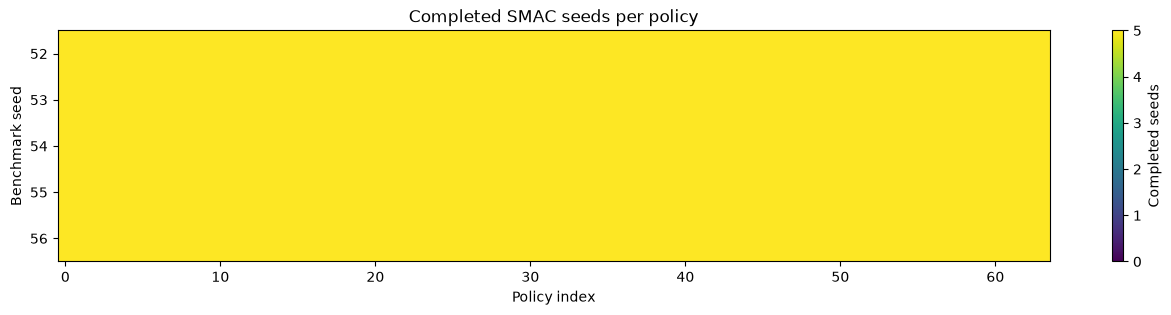

In [4]:
rows=[]; curves={}
for family in ('policies','fixed'):
    for path in sorted((OUTPUT/family).rglob('trajectory.json')):
        d=json.loads(path.read_text()); schedule=tuple(map(int,d['depth_schedule'])); best=np.asarray(d['best_regret'],float)
        bseed=int(d.get('benchmark_seed',d['problem_seed'])); sseed=int(d['smac_seed']); key=(family,bseed,d['policy'],sseed)
        if key in curves: raise ValueError(f'Duplicate {key}')
        curves[key]=best
        rows.append({'family':family,'benchmark_seed':bseed,'smac_seed':sseed,'policy':d['policy'],'schedule':schedule,'d1':schedule[0],'d2':schedule[1],'d3':schedule[2],
          'r250':float(best[249]),'r600':float(best[599]),'final_regret':float(best[-1]),'mean_regret':float(best.mean()),'log_auc':float(np.log10(np.maximum(best,1e-300)).mean()),
          'n_trials':int(d['n_trials']),'pythonhashseed':str(d['pythonhashseed']),'path':path})
results=pd.DataFrame(rows)
if results.empty: raise FileNotFoundError(f'No trajectories below {OUTPUT}.')
bad=results[(results.n_trials!=1000) | (results.pythonhashseed!='12345') | ~results.benchmark_seed.isin(BENCHMARK_SEEDS) | ~results.smac_seed.isin(SMAC_SEEDS)]
if not bad.empty: display(bad); raise ValueError('Incompatible metadata.')
dynamic=results.query("family=='policies'").copy(); fixed=results.query("family=='fixed'").copy()
completion=dynamic.groupby(['benchmark_seed','policy']).smac_seed.nunique().unstack(fill_value=0)
print(f'Loaded {len(dynamic)}/1600 dynamic and {len(fixed)}/100 fixed trajectories.')
display(pd.DataFrame({'complete_policy_seed_pairs':(completion==5).sum(axis=1),'expected':64},index=BENCHMARK_SEEDS))
fig,ax=plt.subplots(figsize=(16,3)); im=ax.imshow(completion.reindex(BENCHMARK_SEEDS).to_numpy(),aspect='auto',vmin=0,vmax=5,cmap='viridis'); ax.set_yticks(range(5),BENCHMARK_SEEDS); ax.set_xlabel('Policy index'); ax.set_ylabel('Benchmark seed'); ax.set_title('Completed SMAC seeds per policy'); fig.colorbar(im,ax=ax,label='Completed seeds'); plt.show()

## Rankings within each benchmark landscape

Policies are first averaged over the five SMAC seeds and then ranked separately within each benchmark seed. Endpoint and full-trajectory performance are both retained.

In [5]:
complete_pairs=dynamic.groupby(['benchmark_seed','policy']).filter(lambda x: x.smac_seed.nunique()==5)
by_benchmark=(complete_pairs.groupby(['benchmark_seed','policy','d1','d2','d3'],as_index=False)
 .agg(mean_r250=('r250','mean'),mean_r600=('r600','mean'),mean_final=('final_regret','mean'),std_final=('final_regret','std'),median_final=('final_regret','median'),mean_regret=('mean_regret','mean'),mean_log_auc=('log_auc','mean')))
by_benchmark['final_rank']=by_benchmark.groupby('benchmark_seed').mean_final.rank(method='average')
by_benchmark['auc_rank']=by_benchmark.groupby('benchmark_seed').mean_log_auc.rank(method='average')
for bseed in BENCHMARK_SEEDS:
    table=by_benchmark.query('benchmark_seed==@bseed').sort_values(['mean_final','mean_regret']).head(10).reset_index(drop=True); table.index=np.arange(1,len(table)+1); table.index.name='rank'
    print(f'\nBenchmark seed {bseed}: top 10 by final regret'); display(table[['policy','d1','d2','d3','mean_r250','mean_r600','mean_final','std_final','mean_log_auc']])


Benchmark seed 52: top 10 by final regret


,policy,d1,d2,d3,mean_r250,mean_r600,mean_final,std_final,mean_log_auc
rank,,,,,,,,,
1,depth_policy_10_15_15,10,15,15,89460.789500,26387.216000,10173.431154,3377.429284,4.604864
2,depth_policy_10_20_15,10,20,15,89460.789500,26915.684246,10750.159628,3714.305412,4.611581
3,depth_policy_10_10_20,10,10,20,89460.789500,22428.137334,10924.671854,3411.491490,4.560490
4,depth_policy_15_10_15,15,10,15,82895.730414,30173.573473,10962.113262,1718.110111,4.633679
5,depth_policy_20_10_15,20,10,15,82895.730414,30173.573473,10962.113262,1718.110111,4.633679
6,depth_policy_10_15_20,10,15,20,89460.789500,26387.216000,11027.196727,3482.722966,4.597286
7,depth_policy_10_10_15,10,10,15,89460.789500,22428.137334,11216.451853,6206.734539,4.578908
8,depth_policy_15_20_15,15,20,15,82895.730414,30088.966051,11353.454164,3156.150492,4.634130
9,depth_policy_20_20_15,20,20,15,82895.730414,30088.966051,11353.454164,3156.150492,4.634130



Benchmark seed 53: top 10 by final regret


,policy,d1,d2,d3,mean_r250,mean_r600,mean_final,std_final,mean_log_auc
rank,,,,,,,,,
1,depth_policy_5_15_15,5,15,15,75098.500250,21370.718678,9123.677218,1964.578972,4.545457
2,depth_policy_5_15_20,5,15,20,75098.500250,21370.718678,10484.350116,3902.963148,4.521834
3,depth_policy_5_10_20,5,10,20,75098.500250,24294.010927,10916.398441,4324.252879,4.522474
4,depth_policy_5_20_20,5,20,20,75098.500250,27457.886768,11476.972883,3390.127232,4.569134
5,depth_policy_10_10_15,10,10,15,69895.722518,25074.470581,11634.244201,3940.638730,4.533074
6,depth_policy_10_10_20,10,10,20,69895.722518,25074.470581,12990.495066,2657.796476,4.546808
7,depth_policy_15_10_20,15,10,20,69247.133854,27808.710182,13171.750088,6734.139829,4.577194
8,depth_policy_20_10_20,20,10,20,69247.133854,27808.710182,13171.750088,6734.139829,4.577194
9,depth_policy_10_15_15,10,15,15,69895.722518,31698.209257,13233.558107,4774.191374,4.597207



Benchmark seed 54: top 10 by final regret


,policy,d1,d2,d3,mean_r250,mean_r600,mean_final,std_final,mean_log_auc
rank,,,,,,,,,
1,depth_policy_5_15_20,5,15,20,90715.459314,25759.143198,10811.401928,5388.787754,4.564852
2,depth_policy_10_20_20,10,20,20,62019.612541,19810.563351,10866.044250,3059.628241,4.493989
3,depth_policy_5_15_15,5,15,15,90715.459314,25759.143198,10874.619054,4818.600222,4.572655
4,depth_policy_10_20_15,10,20,15,62019.612541,19810.563351,11473.645649,5020.153065,4.475955
5,depth_policy_10_15_15,10,15,15,62019.612541,21631.456487,11715.682640,4994.438071,4.517606
6,depth_policy_15_10_20,15,10,20,64786.132673,24897.391924,11720.144365,5554.961032,4.529108
7,depth_policy_20_10_20,20,10,20,64786.132673,24897.391924,11720.144365,5554.961032,4.529108
8,depth_policy_5_20_20,5,20,20,90715.459314,28355.889628,11797.080629,2920.662859,4.597134
9,depth_policy_15_20_20,15,20,20,64786.132673,25428.827841,11858.839857,2577.224513,4.571126



Benchmark seed 55: top 10 by final regret


,policy,d1,d2,d3,mean_r250,mean_r600,mean_final,std_final,mean_log_auc
rank,,,,,,,,,
1,depth_policy_10_20_20,10,20,20,42034.068423,13002.319587,5359.927810,2805.596714,4.295591
2,depth_policy_10_15_20,10,15,20,42034.068423,12147.507591,5898.928146,1461.573983,4.311879
3,depth_policy_10_15_15,10,15,15,42034.068423,12147.507591,6514.494028,2317.220222,4.309744
4,depth_policy_10_10_15,10,10,15,42034.068423,14441.195272,7131.986750,2243.226032,4.362711
5,depth_policy_10_20_15,10,20,15,42034.068423,13002.319587,7286.792950,1990.092242,4.313529
6,depth_policy_15_20_20,15,20,20,47216.445107,19909.771232,7296.948554,4912.800649,4.392364
7,depth_policy_20_20_20,20,20,20,47216.445107,19909.771232,7296.948554,4912.800649,4.392364
8,depth_policy_10_15_10,10,15,10,42034.068423,12147.507591,7457.855751,3395.155330,4.317724
9,depth_policy_5_10_20,5,10,20,66129.058520,17599.364693,7529.516616,2735.959674,4.414664



Benchmark seed 56: top 10 by final regret


,policy,d1,d2,d3,mean_r250,mean_r600,mean_final,std_final,mean_log_auc
rank,,,,,,,,,
1,depth_policy_15_10_15,15,10,15,30829.366484,13053.827376,6514.756746,3693.721919,4.249795
2,depth_policy_20_10_15,20,10,15,30829.366484,13053.827376,6514.756746,3693.721919,4.249795
3,depth_policy_10_20_15,10,20,15,35916.850086,13048.866546,6728.443707,3178.165326,4.275429
4,depth_policy_10_10_20,10,10,20,35916.850086,12854.906971,6847.678276,4019.188352,4.271777
5,depth_policy_15_20_15,15,20,15,30829.366484,14691.804249,6886.375340,3176.526687,4.284255
6,depth_policy_20_20_15,20,20,15,30829.366484,14691.804249,6886.375340,3176.526687,4.284255
7,depth_policy_15_20_20,15,20,20,30829.366484,14691.804249,6966.553600,2747.189152,4.298142
8,depth_policy_20_20_20,20,20,20,30829.366484,14691.804249,6966.553600,2747.189152,4.298142
9,depth_policy_15_15_15,15,15,15,30829.366484,16395.220879,6970.866727,2444.751390,4.311802


## Which depths occur in the best schedules, and at which stage?

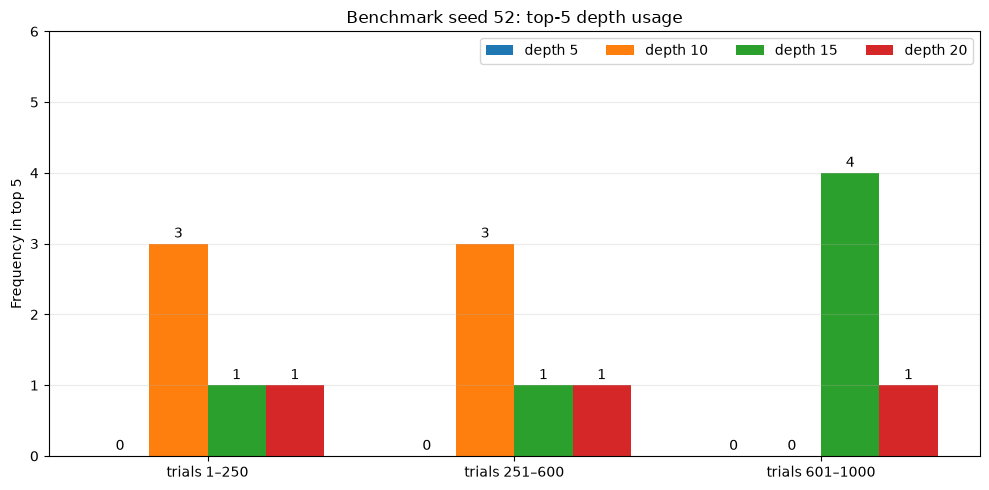

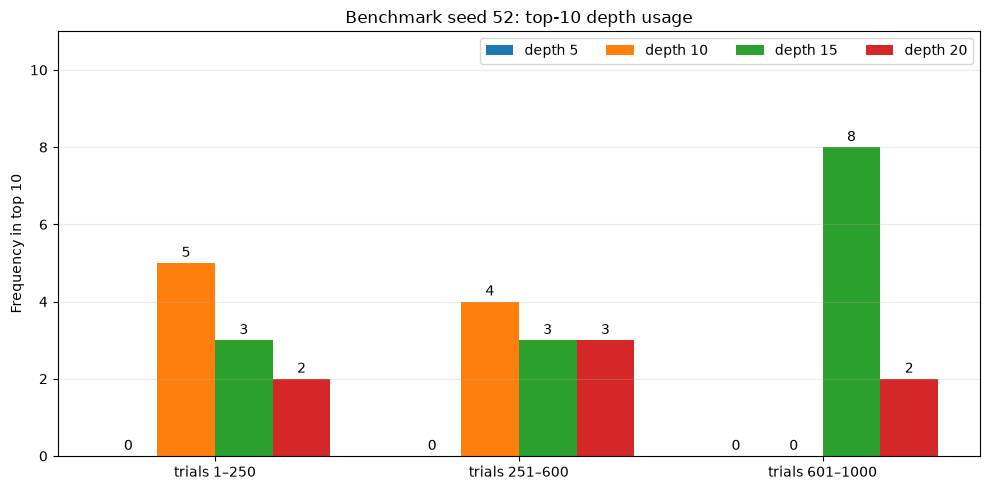

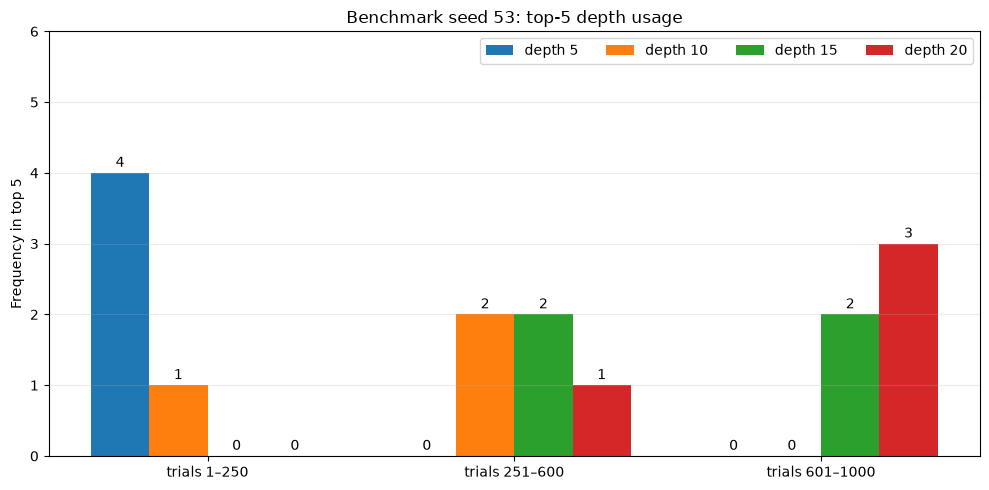

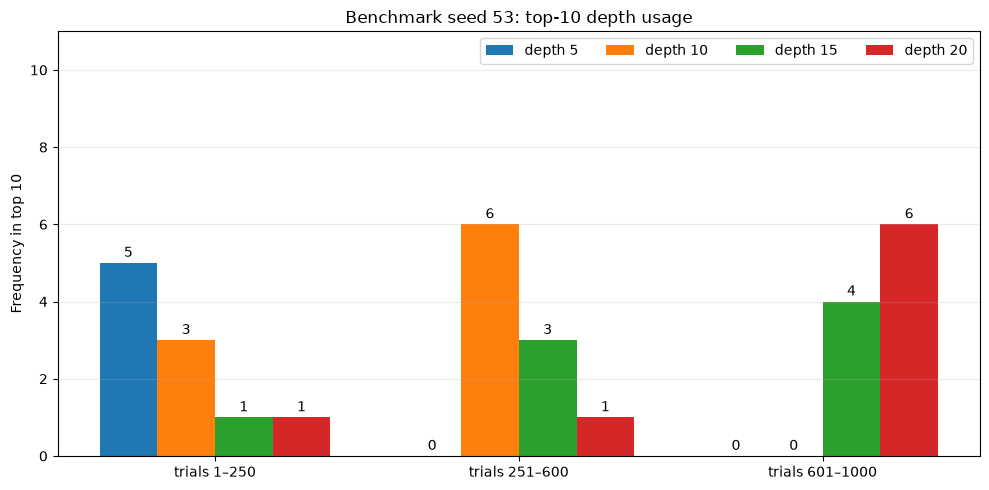

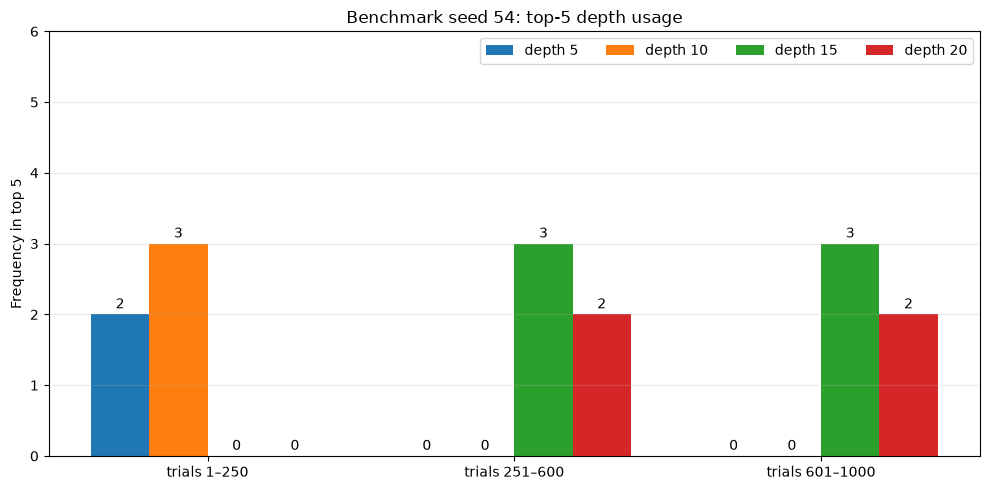

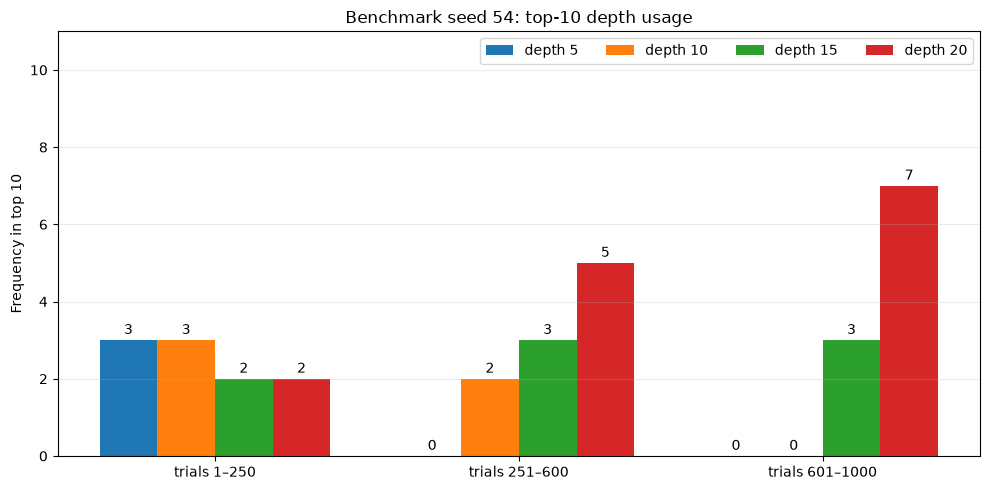

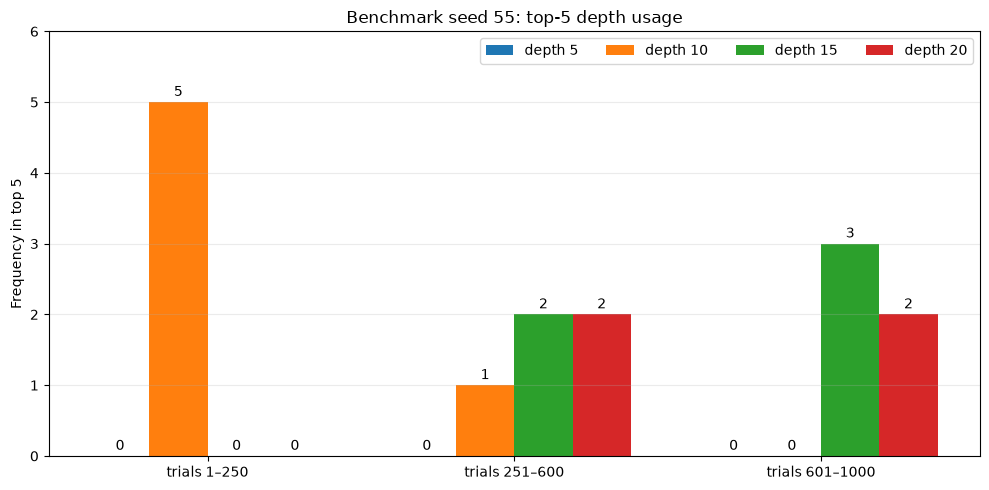

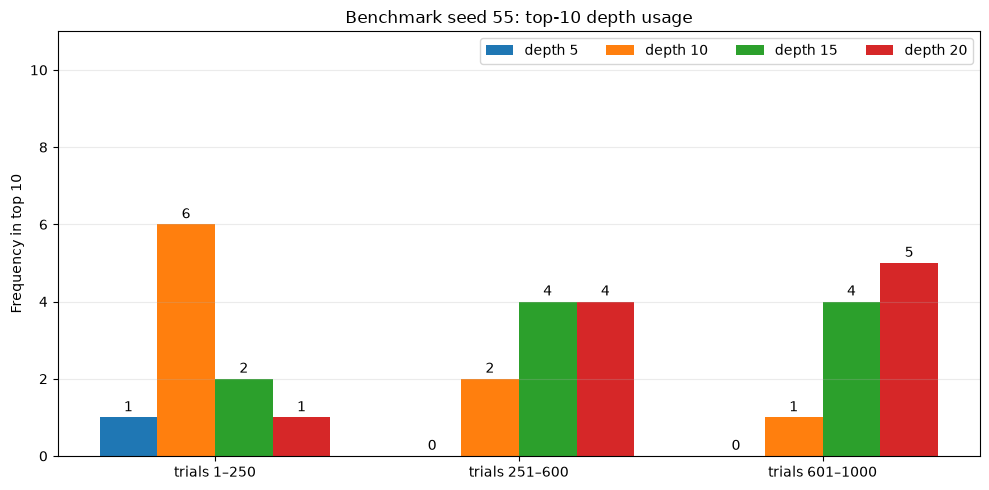

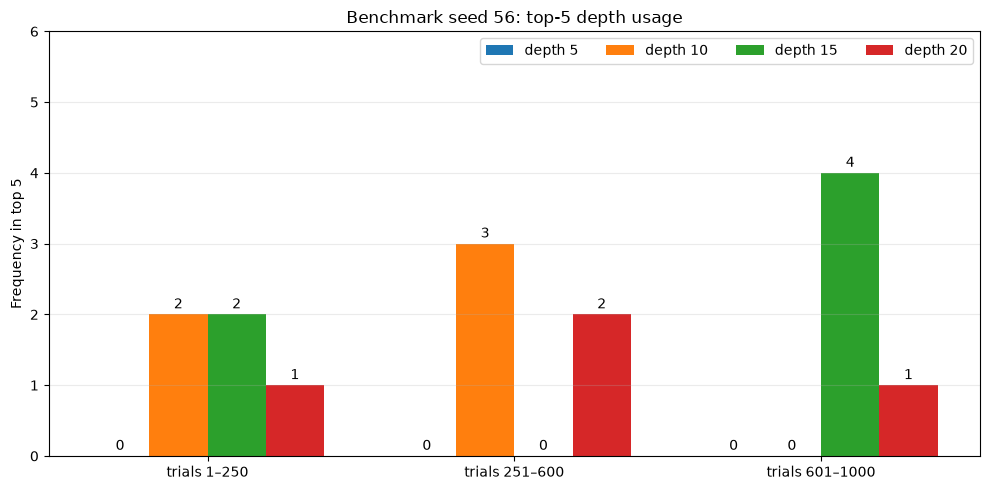

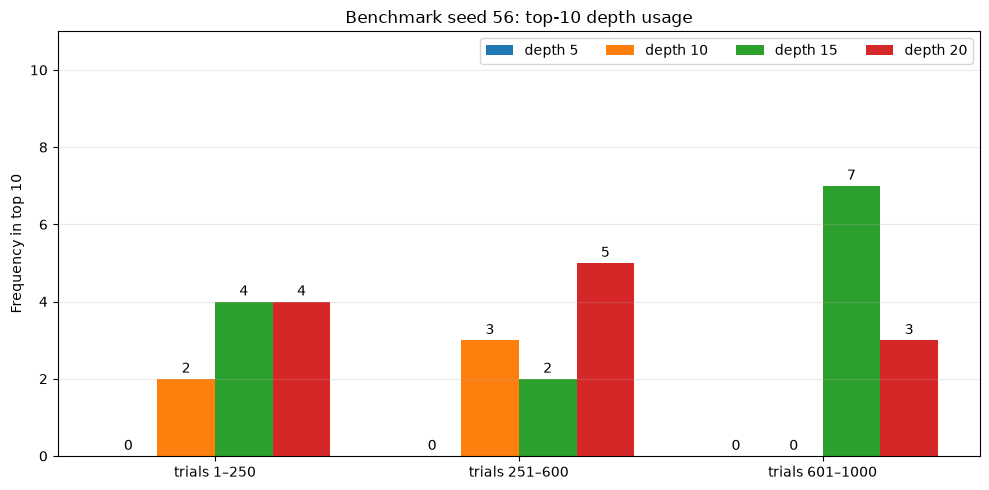

In [6]:
def frequency_chart(bseed,n):
    top=by_benchmark.query('benchmark_seed==@bseed').nsmallest(n,'mean_final'); x=np.arange(3); width=.19; fig,ax=plt.subplots(figsize=(10,5))
    for i,depth in enumerate(DEPTHS):
        vals=[int((top[f'd{s}']==depth).sum()) for s in (1,2,3)]; bars=ax.bar(x+(i-1.5)*width,vals,width,label=f'depth {depth}'); ax.bar_label(bars,padding=2)
    ax.set_xticks(x,STAGES); ax.set_ylim(0,n+1); ax.set_ylabel(f'Frequency in top {n}'); ax.set_title(f'Benchmark seed {bseed}: top-{n} depth usage'); ax.legend(ncol=4); ax.grid(axis='y',alpha=.25); plt.tight_layout(); plt.show()
for bseed in BENCHMARK_SEEDS:
    frequency_chart(bseed,5); frequency_chart(bseed,10)

## Marginal stage associations

These plots average over all choices in the other stages. They are useful for detecting broad depth preferences, but they are not causal stage effects because later performance depends on the earlier search path.

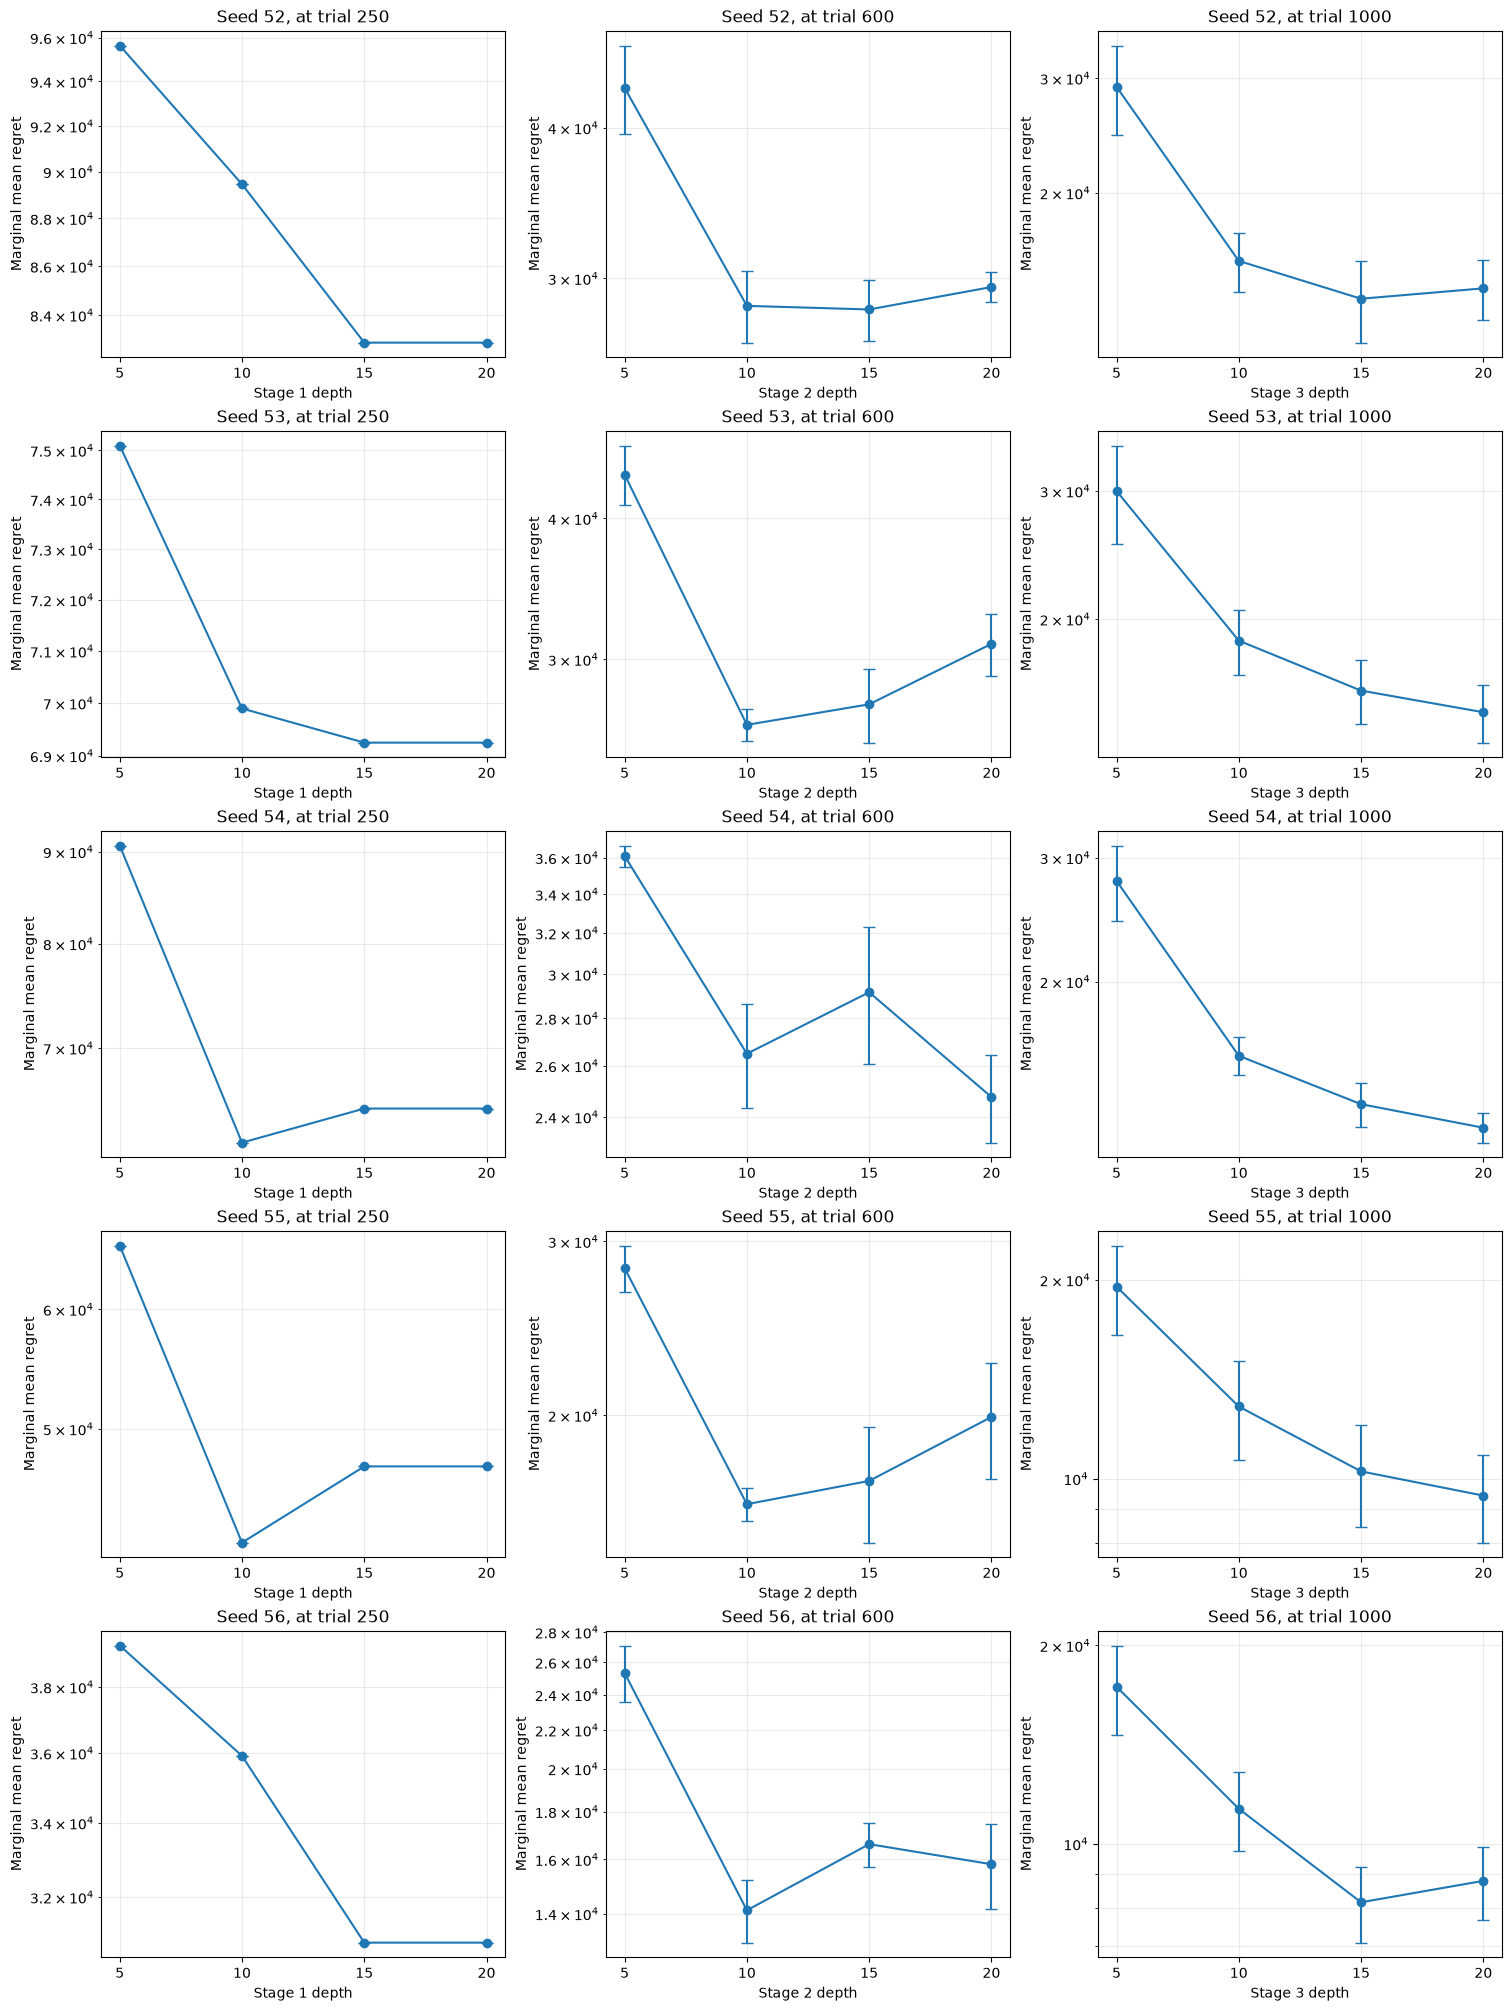

In [7]:
fig,axes=plt.subplots(5,3,figsize=(15,20),constrained_layout=True)
for row,bseed in enumerate(BENCHMARK_SEEDS):
    sub=by_benchmark.query('benchmark_seed==@bseed')
    for col,(stage,metric,title) in enumerate([(1,'mean_r250','at trial 250'),(2,'mean_r600','at trial 600'),(3,'mean_final','at trial 1000')]):
        stats=sub.groupby(f'd{stage}')[metric].agg(['mean','std','count']).reindex(DEPTHS); sem=stats['std']/np.sqrt(stats['count']); axes[row,col].errorbar(DEPTHS,stats['mean'],yerr=t.ppf(.975,stats['count']-1)*sem,marker='o',capsize=4)
        axes[row,col].set_yscale('log'); axes[row,col].set_xticks(DEPTHS); axes[row,col].set_xlabel(f'Stage {stage} depth'); axes[row,col].set_ylabel('Marginal mean regret'); axes[row,col].set_title(f'Seed {bseed}, {title}'); axes[row,col].grid(alpha=.25,which='both')
plt.show()

## Top policies and trajectories within each benchmark seed

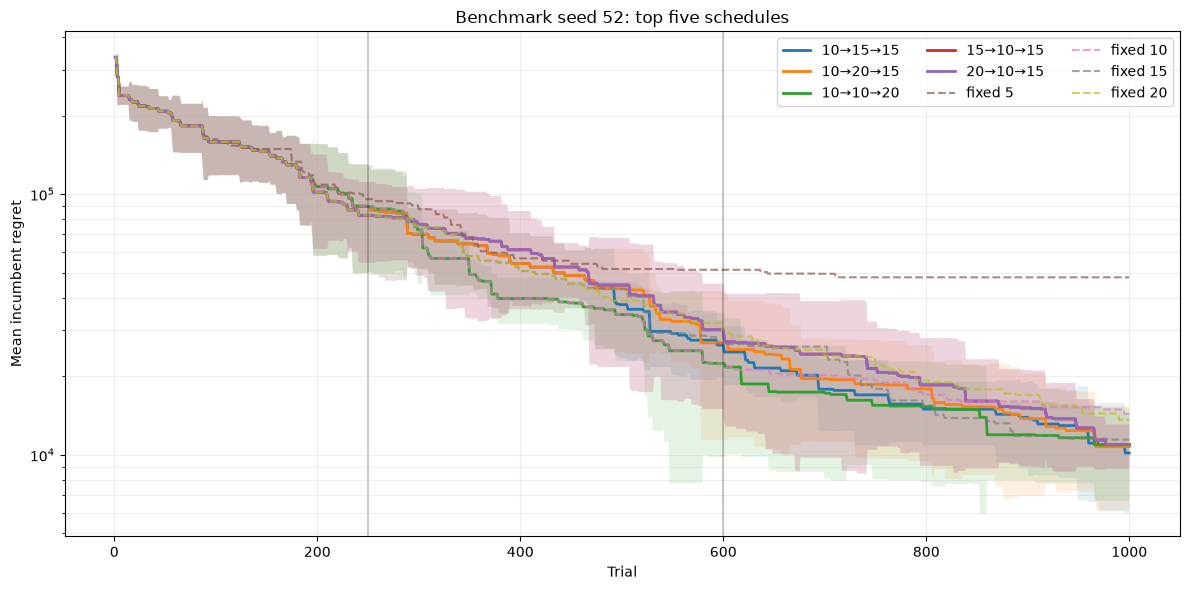

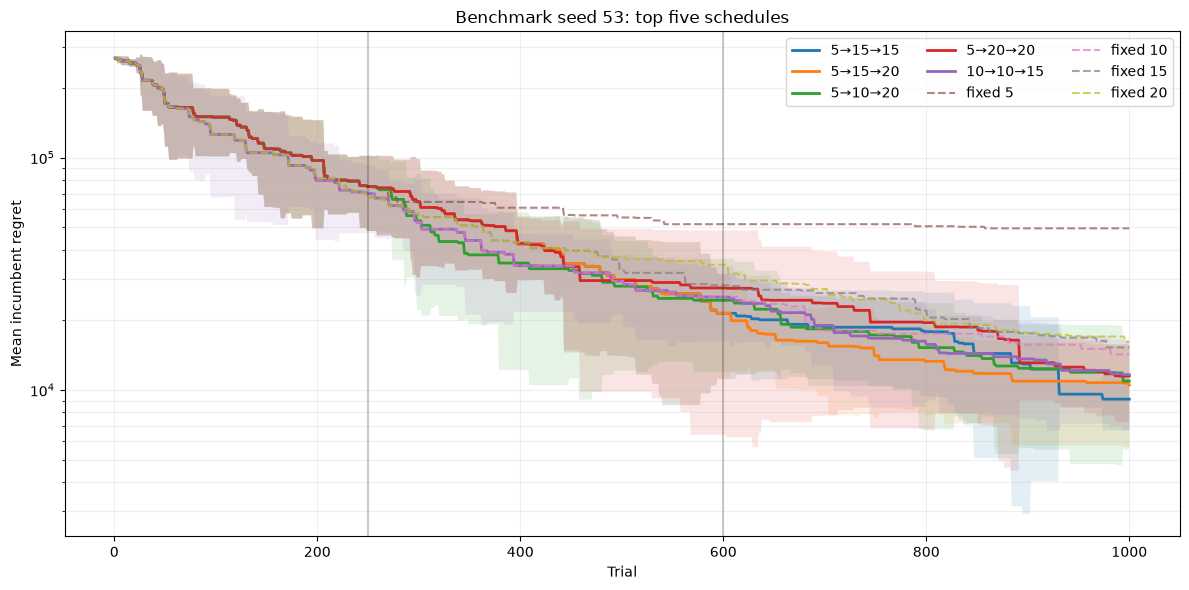

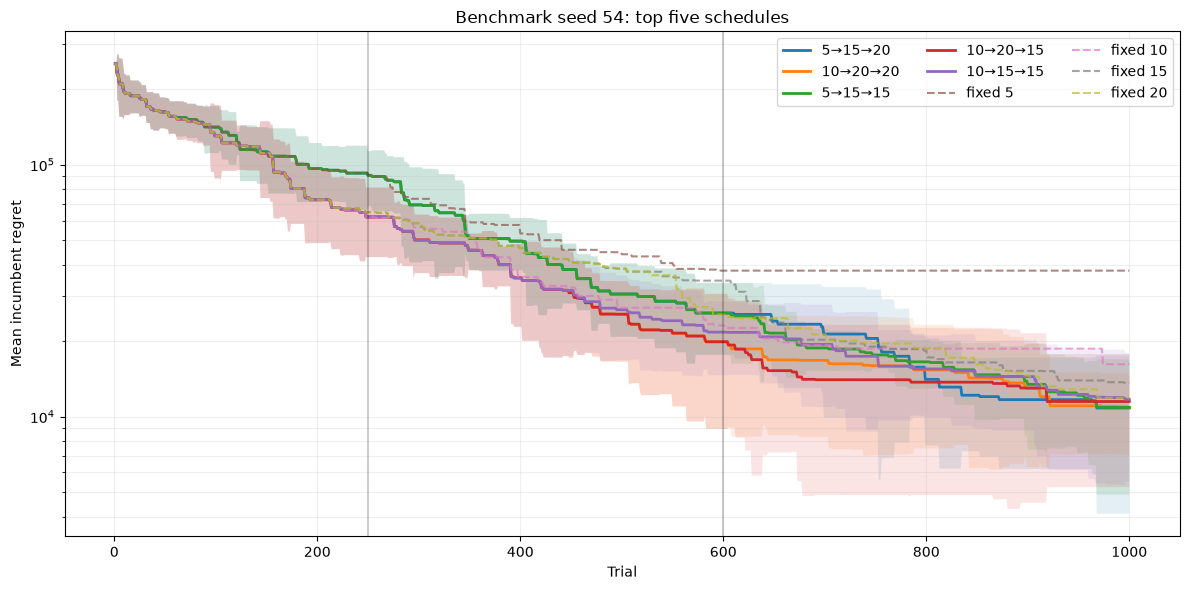

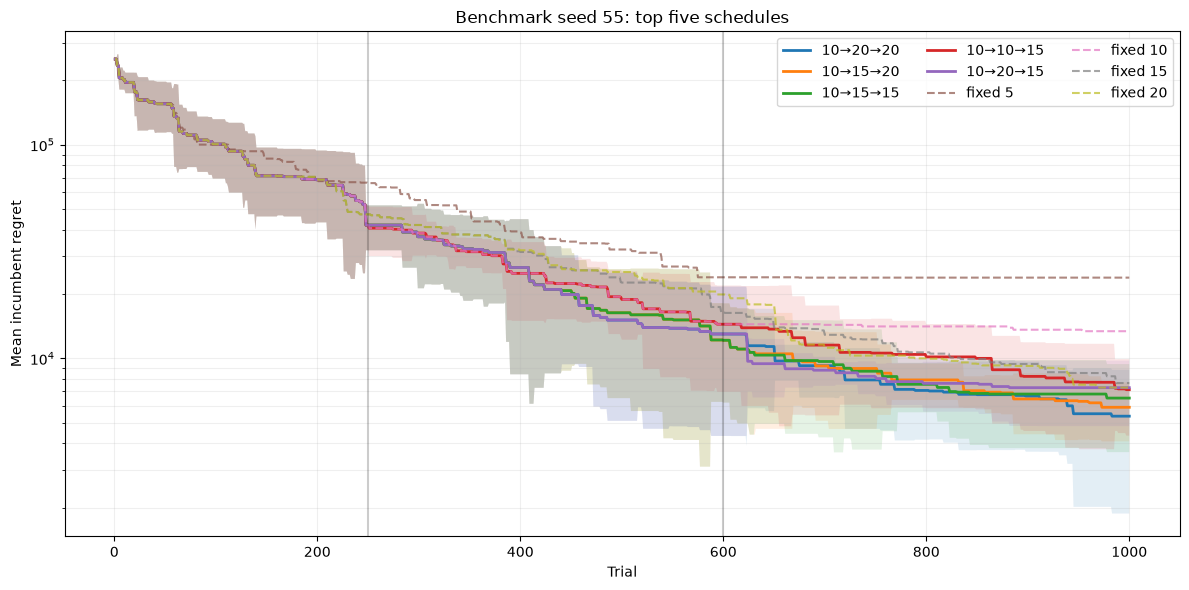

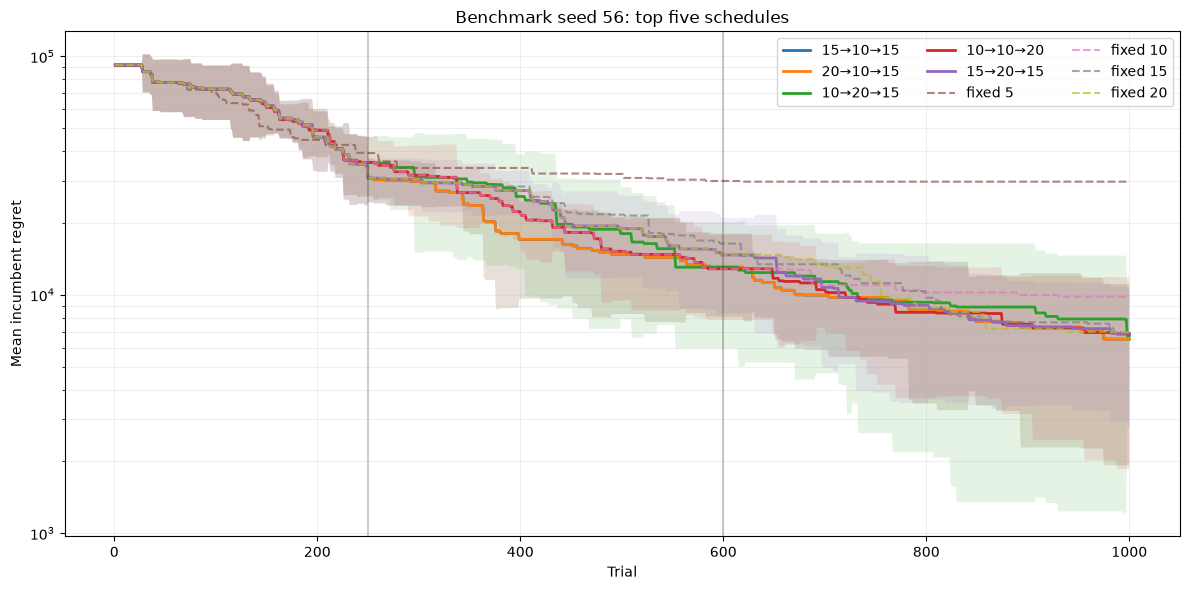

In [8]:
for bseed in BENCHMARK_SEEDS:
    top=by_benchmark.query('benchmark_seed==@bseed').nsmallest(5,'mean_final').policy.tolist(); fig,ax=plt.subplots(figsize=(12,6))
    for policy in top:
        m=np.vstack([curves[('policies',bseed,policy,s)] for s in SMAC_SEEDS]); mean=m.mean(0); margin=t.ppf(.975,4)*m.std(0,ddof=1)/np.sqrt(5); x=np.arange(1,1001); label=policy.replace('depth_policy_','').replace('_','→')
        ax.plot(x,np.maximum(mean,1e-300),lw=2,label=label); ax.fill_between(x,np.maximum(mean-margin,1e-300),np.maximum(mean+margin,1e-300),alpha=.12)
    for d in DEPTHS:
        fixed_keys=[('fixed',bseed,f'fixed_depth_{d}',s) for s in SMAC_SEEDS]
        if all(key in curves for key in fixed_keys):
            m=np.vstack([curves[('fixed',bseed,f'fixed_depth_{d}',s)] for s in SMAC_SEEDS]); ax.plot(np.arange(1,1001),np.maximum(m.mean(0),1e-300),ls='--',alpha=.7,label=f'fixed {d}')
    for boundary in (250,600): ax.axvline(boundary,color='black',alpha=.2)
    ax.set_yscale('log'); ax.set_xlabel('Trial'); ax.set_ylabel('Mean incumbent regret'); ax.set_title(f'Benchmark seed {bseed}: top five schedules'); ax.legend(ncol=3); ax.grid(alpha=.2,which='both'); plt.tight_layout(); plt.show()

# What works across benchmark seeds

Raw regret scales differ between O1 landscapes, so cross-landscape aggregation uses within-landscape ranks and ratios to that landscape's best observed schedule.

,policy,d1,d2,d3,mean_rank,median_rank,worst_rank,rank_std,geomean_ratio,mean_auc_rank,top5_landscapes
cross-seed rank,,,,,,,,,,,
1,depth_policy_10_20_15,10,20,15,5.4,4.0,13.0,4.393177,1.198754,5.6,4
2,depth_policy_10_15_15,10,15,15,7.2,5.0,18.0,6.723095,1.187408,10.8,3
3,depth_policy_10_20_20,10,20,20,8.4,12.0,15.0,6.426508,1.163396,5.2,2
4,depth_policy_10_10_20,10,10,20,8.8,6.0,19.0,6.685806,1.236917,4.8,2
5,depth_policy_10_10_15,10,10,15,10.2,7.0,23.0,7.791020,1.219840,6.8,2
6,depth_policy_15_10_15,15,10,15,12.3,15.5,20.5,8.757854,1.295389,13.9,2
7,depth_policy_20_10_15,20,10,15,12.3,15.5,20.5,8.757854,1.295389,13.9,2
8,depth_policy_15_20_20,15,20,20,13.3,9.5,22.5,7.596052,1.303943,19.3,0
9,depth_policy_20_20_20,20,20,20,13.3,9.5,22.5,7.596052,1.303943,19.3,0


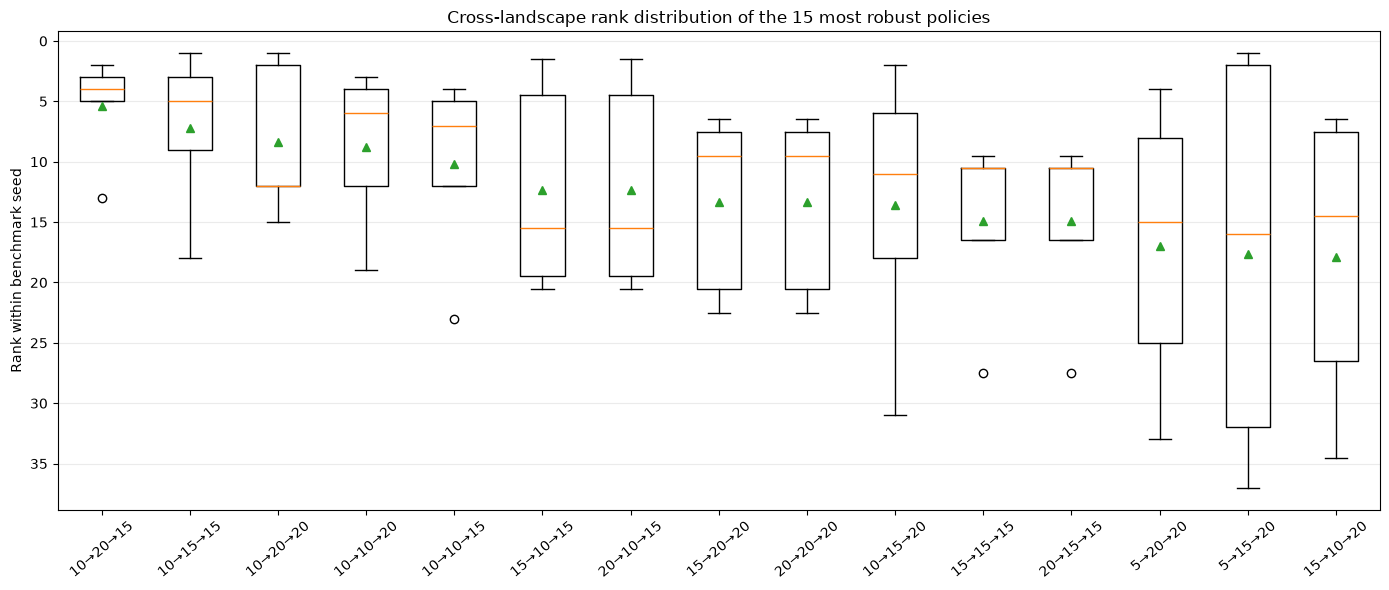

In [9]:
if any(by_benchmark.query('benchmark_seed==@b').policy.nunique()!=64 for b in BENCHMARK_SEEDS): raise ValueError('Cross-benchmark analysis requires all 64 schedules on every benchmark seed.')
by_benchmark['best_mean']=by_benchmark.groupby('benchmark_seed').mean_final.transform('min'); by_benchmark['ratio_to_best']=by_benchmark.mean_final/by_benchmark.best_mean
cross=(by_benchmark.groupby(['policy','d1','d2','d3'],as_index=False)
 .agg(mean_rank=('final_rank','mean'),median_rank=('final_rank','median'),worst_rank=('final_rank','max'),rank_std=('final_rank','std'),geomean_ratio=('ratio_to_best',lambda x: float(np.exp(np.log(x).mean()))),mean_auc_rank=('auc_rank','mean')))
cross['top5_landscapes']=cross.policy.map(by_benchmark.query('final_rank<=5').groupby('policy').size()).fillna(0).astype(int)
cross=cross.sort_values(['mean_rank','geomean_ratio','worst_rank']).reset_index(drop=True); cross.index=np.arange(1,len(cross)+1); cross.index.name='cross-seed rank'
display(cross.head(15))
fig,ax=plt.subplots(figsize=(14,6)); top=cross.head(15); rank_lists=[by_benchmark.query('policy==@p').sort_values('benchmark_seed').final_rank for p in top.policy]; labels=[p.replace('depth_policy_','').replace('_','→') for p in top.policy]
ax.boxplot(rank_lists,tick_labels=labels,showmeans=True); ax.set_ylabel('Rank within benchmark seed'); ax.invert_yaxis(); ax.set_title('Cross-landscape rank distribution of the 15 most robust policies'); ax.tick_params(axis='x',rotation=40); ax.grid(axis='y',alpha=.25); plt.tight_layout(); plt.show()

### Paired 25-run rank distribution

This complementary view ranks the 64 policies separately for every matched `(benchmark seed, SMAC seed)` pair. Each boxplot therefore contains 25 ranks: five SMAC seeds on each of five benchmark seeds. The points are descriptive rather than independent observations because five share each benchmark landscape.

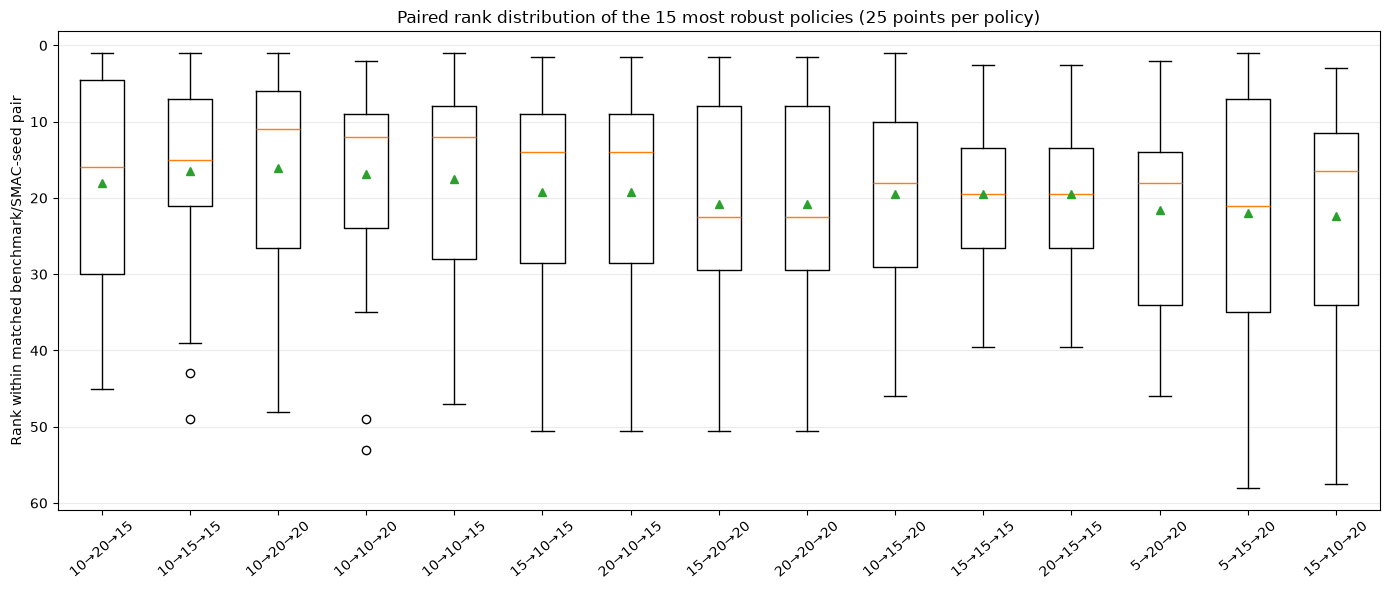

In [14]:
paired_ranks = complete_pairs.copy()
pair_sizes = paired_ranks.groupby(['benchmark_seed', 'smac_seed']).policy.nunique()
if not pair_sizes.eq(64).all():
    raise ValueError('Paired-rank analysis requires all 64 policies for every benchmark/SMAC-seed pair.')
paired_ranks['paired_final_rank'] = paired_ranks.groupby(['benchmark_seed', 'smac_seed']).final_regret.rank(method='average')
expected_points = len(BENCHMARK_SEEDS) * len(SMAC_SEEDS)
point_counts = paired_ranks.groupby('policy').size()
if not point_counts.eq(expected_points).all():
    raise ValueError(f'Expected {expected_points} paired ranks per policy.')
rank_lists = [paired_ranks.query('policy == @p').sort_values(['benchmark_seed', 'smac_seed']).paired_final_rank for p in top.policy]
fig, ax = plt.subplots(figsize=(14, 6))
ax.boxplot(rank_lists, tick_labels=labels, showmeans=True)
ax.set_ylabel('Rank within matched benchmark/SMAC-seed pair')
ax.invert_yaxis()
ax.set_title(f'Paired rank distribution of the 15 most robust policies ({expected_points} points per policy)')
ax.tick_params(axis='x', rotation=40)
ax.grid(axis='y', alpha=.25)
plt.tight_layout()
plt.show()


## Cross-landscape stage preferences

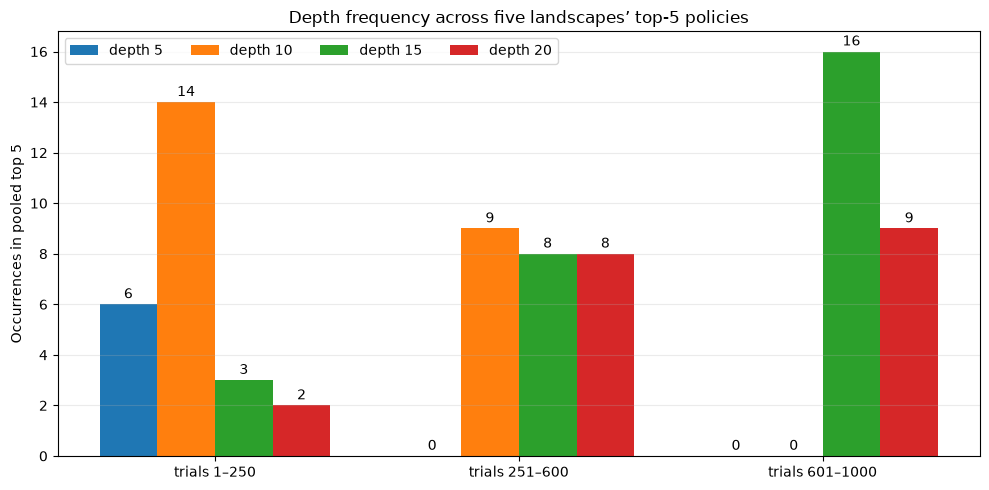

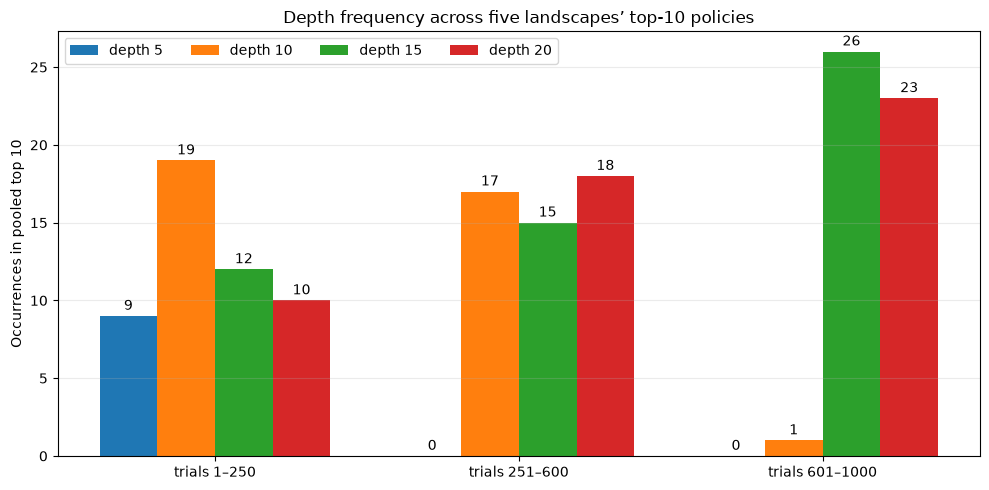

In [10]:
for n in (5,10):
    selected=by_benchmark.sort_values(['benchmark_seed','mean_final']).groupby('benchmark_seed').head(n); x=np.arange(3); width=.19; fig,ax=plt.subplots(figsize=(10,5))
    for i,depth in enumerate(DEPTHS):
        vals=[int((selected[f'd{s}']==depth).sum()) for s in (1,2,3)]; bars=ax.bar(x+(i-1.5)*width,vals,width,label=f'depth {depth}'); ax.bar_label(bars,padding=2)
    ax.set_xticks(x,STAGES); ax.set_ylabel(f'Occurrences in pooled top {n}'); ax.set_title(f'Depth frequency across five landscapes’ top-{n} policies'); ax.legend(ncol=4); ax.grid(axis='y',alpha=.25); plt.tight_layout(); plt.show()

## Do policy rankings agree between benchmark seeds?

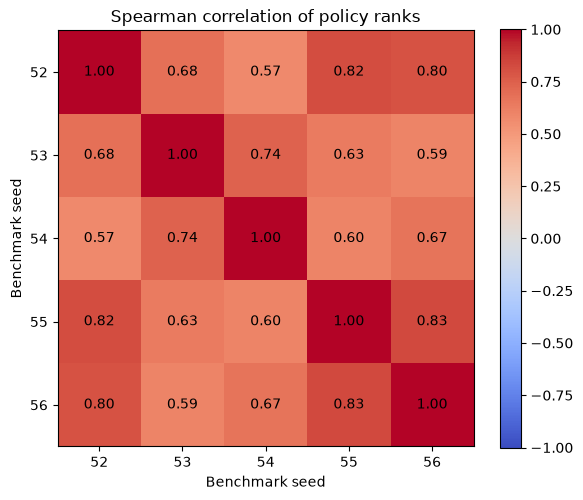

benchmark_seed,52,53,54,55,56
benchmark_seed,,,,,
52,1.000000,0.684637,0.573562,0.817928,0.796995
53,0.684637,1.000000,0.738366,0.634985,0.594586
54,0.573562,0.738366,1.000000,0.597792,0.667186
55,0.817928,0.634985,0.597792,1.000000,0.831852
56,0.796995,0.594586,0.667186,0.831852,1.000000


In [11]:
rank_matrix=by_benchmark.pivot(index='policy',columns='benchmark_seed',values='final_rank').reindex(columns=BENCHMARK_SEEDS); corr=rank_matrix.corr(method='spearman')
fig,ax=plt.subplots(figsize=(6,5)); im=ax.imshow(corr,vmin=-1,vmax=1,cmap='coolwarm'); ax.set_xticks(range(5),BENCHMARK_SEEDS); ax.set_yticks(range(5),BENCHMARK_SEEDS); ax.set_xlabel('Benchmark seed'); ax.set_ylabel('Benchmark seed'); ax.set_title('Spearman correlation of policy ranks')
for i in range(5):
    for j in range(5): ax.text(j,i,f'{corr.iloc[i,j]:.2f}',ha='center',va='center')
fig.colorbar(im,ax=ax); plt.tight_layout(); plt.show(); display(corr)

## Leave-one-benchmark-seed-out policy selection

For each held-out landscape, select a policy only using the other four landscapes, then report its held-out rank. This approximates how well a schedule chosen now might transfer to a new O1 instance.

In [12]:
lobo=[]
for held_out in BENCHMARK_SEEDS:
    train=by_benchmark.query('benchmark_seed!=@held_out').groupby('policy').agg(train_mean_rank=('final_rank','mean'),train_worst_rank=('final_rank','max')).sort_values(['train_mean_rank','train_worst_rank']); chosen=train.index[0]
    test=by_benchmark.query('benchmark_seed==@held_out and policy==@chosen').iloc[0]; lobo.append({'held_out_seed':held_out,'selected_policy':chosen,'train_mean_rank':train.iloc[0].train_mean_rank,'held_out_rank':test.final_rank,'held_out_ratio_to_best':test.ratio_to_best})
lobo=pd.DataFrame(lobo); display(lobo); print(f'Mean held-out rank: {lobo.held_out_rank.mean():.2f}/64')

,held_out_seed,selected_policy,train_mean_rank,held_out_rank,held_out_ratio_to_best
0,52,depth_policy_10_20_15,6.25,2.0,1.056690
1,53,depth_policy_10_20_15,3.50,13.0,1.572135
2,54,depth_policy_10_20_15,5.75,4.0,1.061254
3,55,depth_policy_10_20_15,5.50,5.0,1.359495
4,56,depth_policy_10_15_15,4.50,18.0,1.235624


Mean held-out rank: 8.40/64


## Schedule-shape comparison and the full policy landscape

,policies,mean_cross_rank,median_cross_rank,best_cross_rank
shape,,,,
nondecreasing,16,20.950000,18.50,7.2
constant,4,30.750000,23.15,13.3
mixed,28,33.692857,32.70,5.4
nonincreasing,16,42.400000,47.55,14.9


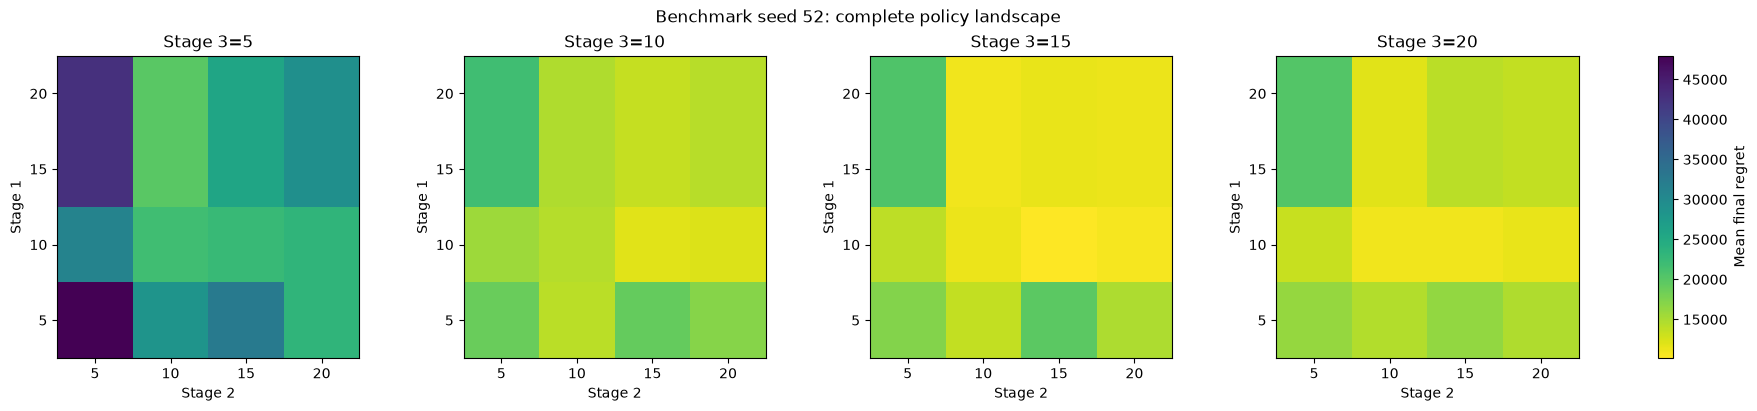

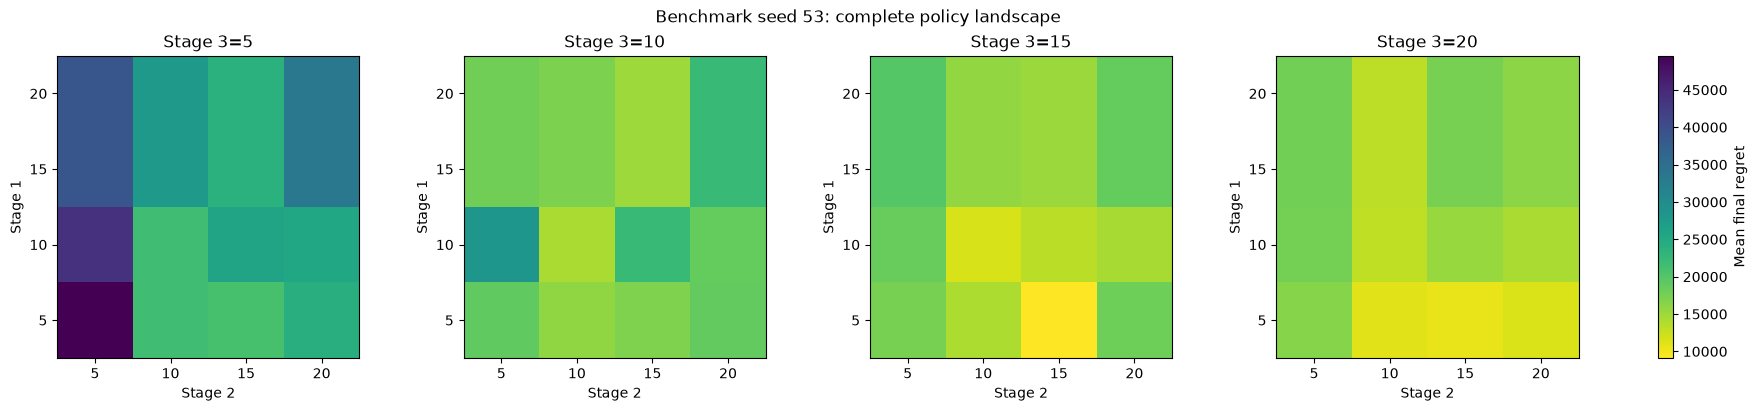

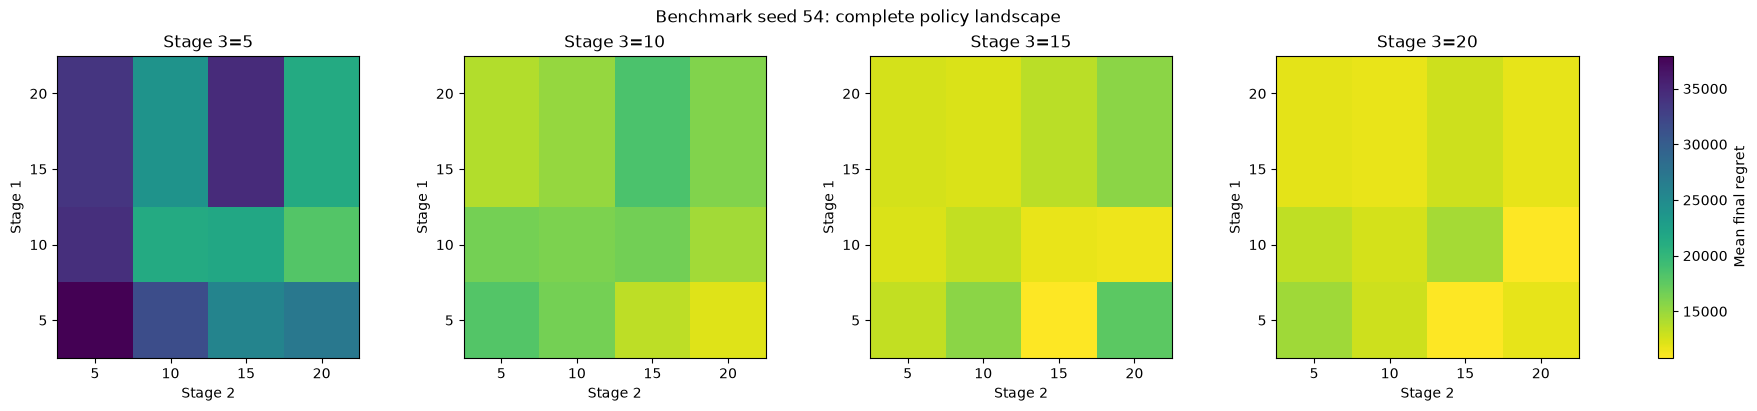

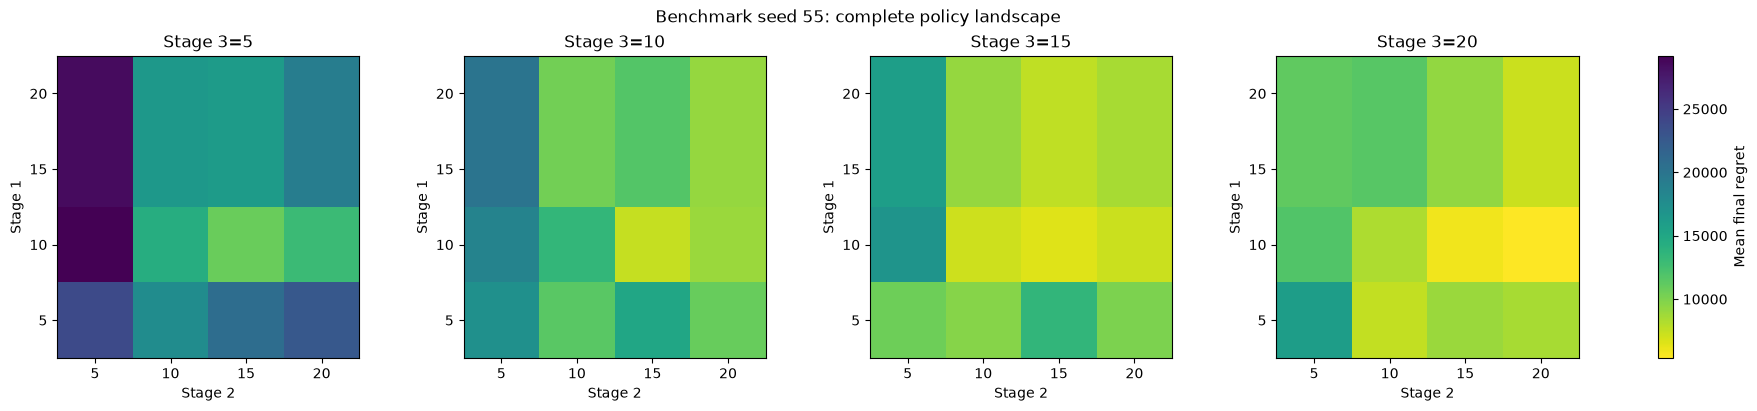

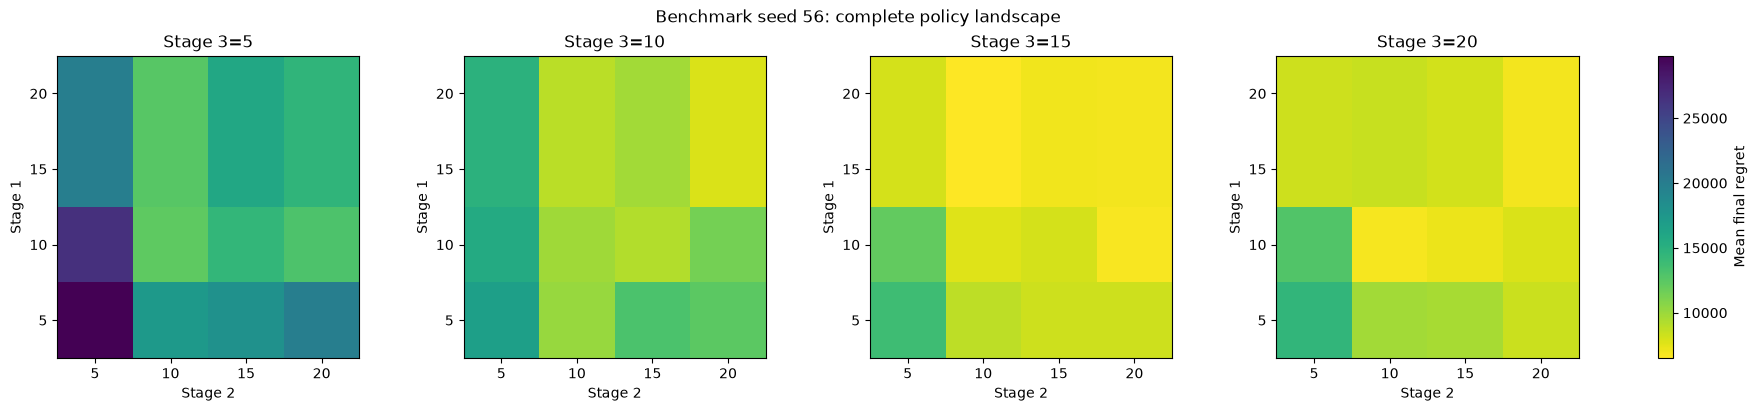

In [13]:
def shape(row):
    d=(row.d1,row.d2,row.d3)
    if len(set(d))==1:return 'constant'
    if d[0]<=d[1]<=d[2]:return 'nondecreasing'
    if d[0]>=d[1]>=d[2]:return 'nonincreasing'
    return 'mixed'
cross['shape']=cross.apply(shape,axis=1); display(cross.groupby('shape').agg(policies=('policy','size'),mean_cross_rank=('mean_rank','mean'),median_cross_rank=('mean_rank','median'),best_cross_rank=('mean_rank','min')).sort_values('mean_cross_rank'))
for bseed in BENCHMARK_SEEDS:
    sub=by_benchmark.query('benchmark_seed==@bseed'); fig,axes=plt.subplots(1,4,figsize=(18,4),constrained_layout=True); vmin=sub.mean_final.min(); vmax=sub.mean_final.max()
    for ax,d3 in zip(axes,DEPTHS):
        pivot=sub.query('d3==@d3').pivot(index='d1',columns='d2',values='mean_final').reindex(index=DEPTHS,columns=DEPTHS); im=ax.imshow(pivot,origin='lower',cmap='viridis_r',vmin=vmin,vmax=vmax); ax.set_xticks(range(4),DEPTHS); ax.set_yticks(range(4),DEPTHS); ax.set_xlabel('Stage 2'); ax.set_ylabel('Stage 1'); ax.set_title(f'Stage 3={d3}')
    fig.colorbar(im,ax=axes,label='Mean final regret'); fig.suptitle(f'Benchmark seed {bseed}: complete policy landscape'); plt.show()

## Notes for interpretation

Useful questions for the follow-up discussion:

- Are early-stage depth preferences consistent across benchmark seeds?
- Do endpoint winners also have good log-regret AUC, or do they win through late lucky improvements?
- Are rank correlations strong enough to justify one global schedule?
- Does leave-one-seed-out selection produce acceptable held-out ranks?
- Are monotone conservative-to-flexible schedules robust, or are mixed schedules consistently better?
- Remember that marginal stage plots are path-dependent associations, not isolated causal effects.